In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/student_performance.csv')

In [2]:
df.head()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [3]:
df['Gender'].value_counts()

,count
Gender,
1,7729
0,6274


In [4]:
df.shape

(14003, 16)

In [5]:
df.columns

Index(['StudyHours', 'Attendance', 'Resources', 'Extracurricular',
       'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle',
       'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore',
       'EduTech', 'StressLevel', 'FinalGrade'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  int64
dtypes: i

In [7]:
df.isnull().sum()

,0
StudyHours,0
Attendance,0
Resources,0
Extracurricular,0
Motivation,0
Internet,0
Gender,0
Age,0
LearningStyle,0
OnlineCourses,0


In [8]:
df.duplicated().sum()

np.int64(1534)

In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.shape

(12469, 16)

MODULE 2: EDA

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df['FinalGrade'] = df['FinalGrade'].replace({
    0: 0,   # Excellent
    1: 1,   # Good
    2: 2,   # Average
    3: 3    # Poor
})

In [14]:
df['FinalGrade'].value_counts()

,count
FinalGrade,
0,3401
2,3221
1,2943
3,2904


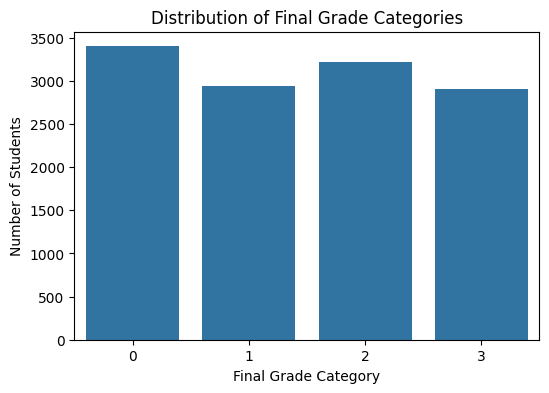

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x='FinalGrade', data=df)

plt.title('Distribution of Final Grade Categories')
plt.xlabel('Final Grade Category')
plt.ylabel('Number of Students')

plt.show()

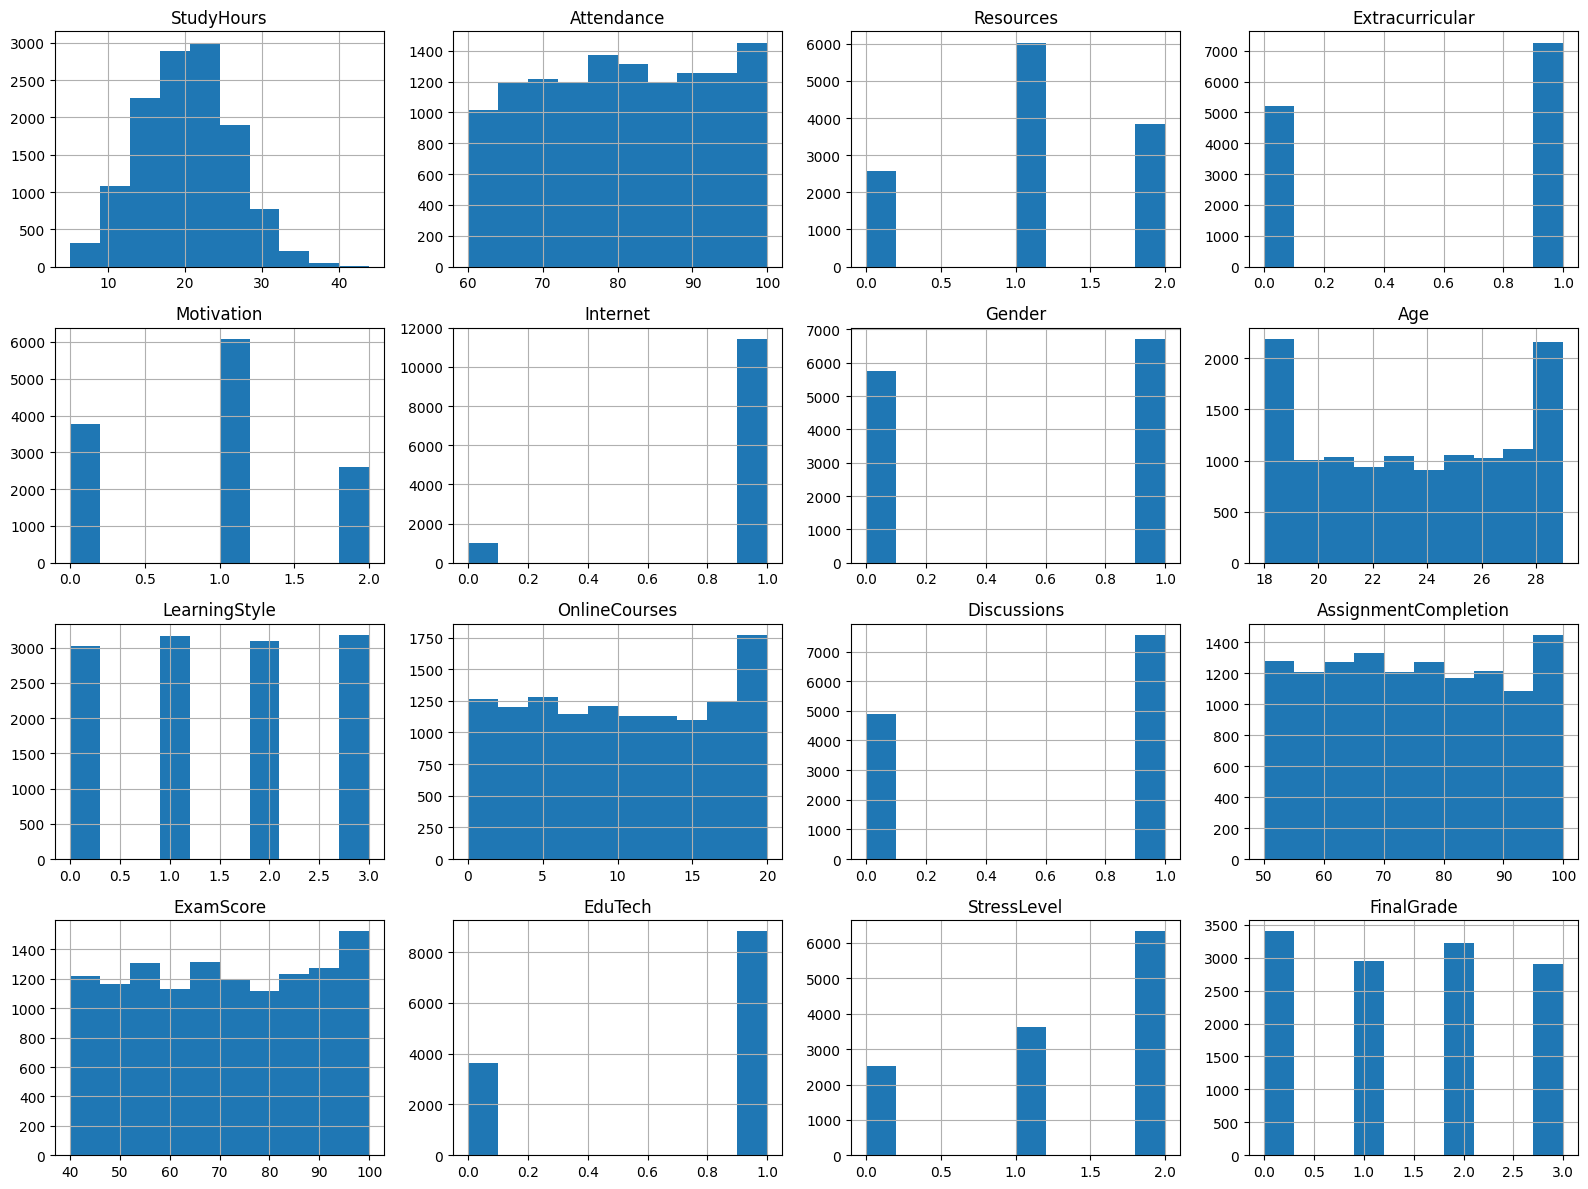

In [16]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numerical_cols].hist(figsize=(16,12))

plt.tight_layout()
plt.show()

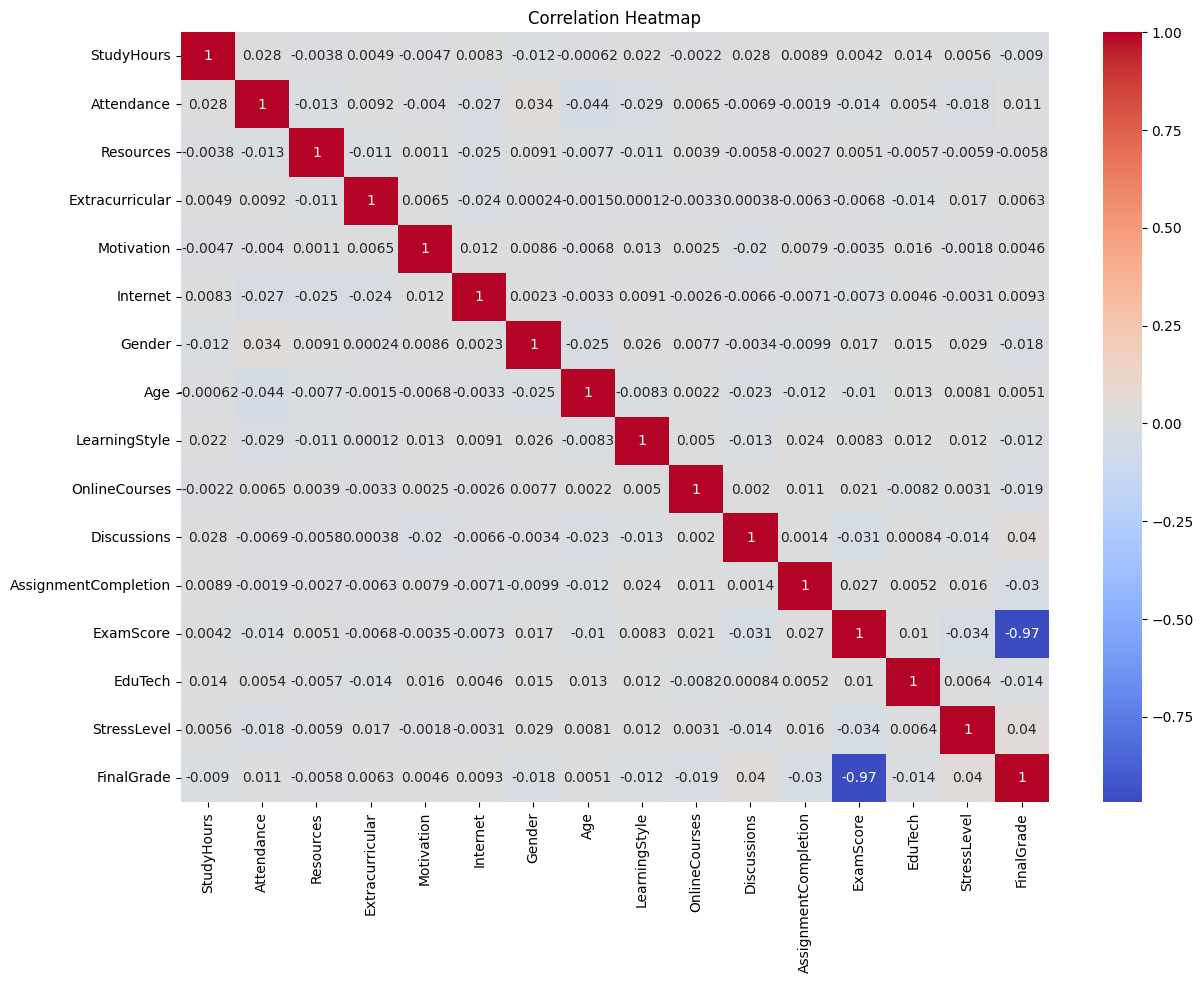

In [17]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

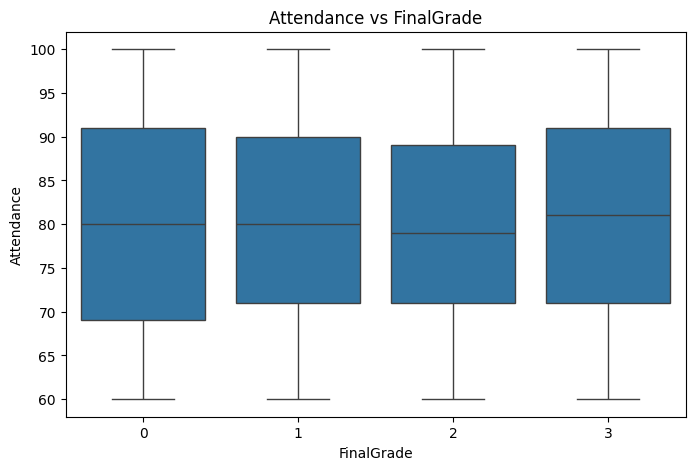

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(x='FinalGrade', y='Attendance', data=df)

plt.title('Attendance vs FinalGrade')

plt.show()

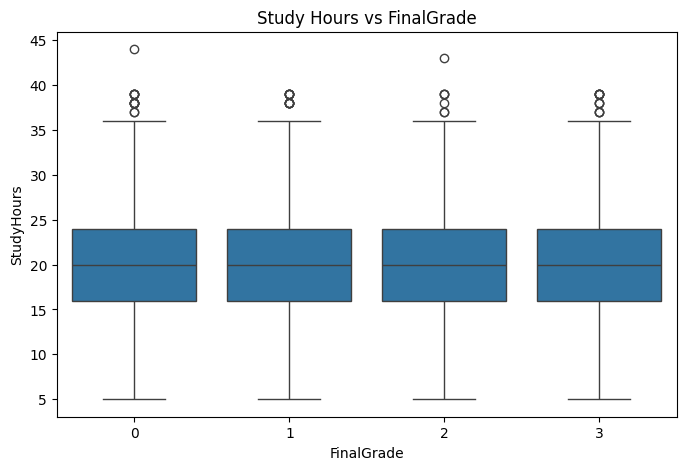

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(x='FinalGrade', y='StudyHours', data=df)

plt.title('Study Hours vs FinalGrade')

plt.show()

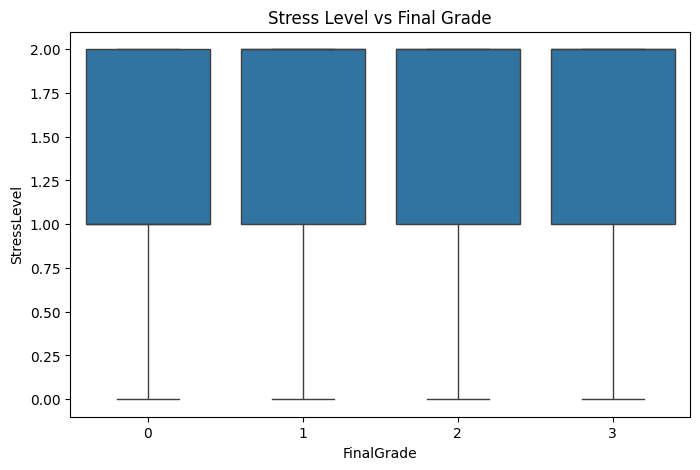

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(x='FinalGrade', y='StressLevel', data=df)

plt.title('Stress Level vs Final Grade')

plt.show()

The StressLevel distribution appeared relatively similar across all FinalGrade categories, suggesting that stress may not significantly differentiate student performance within this dataset.


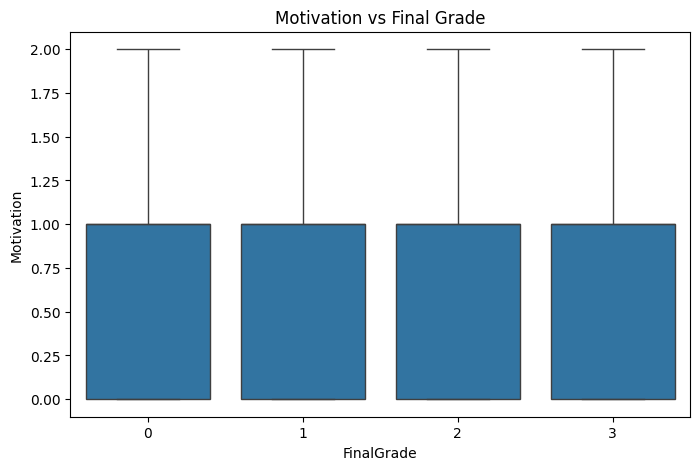

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x='FinalGrade', y='Motivation', data=df)

plt.title('Motivation vs Final Grade')

plt.show()

In [22]:
df.corr(numeric_only=True)['FinalGrade'].sort_values(ascending=False)

,FinalGrade
FinalGrade,1.000000
StressLevel,0.040375
Discussions,0.039817
Attendance,0.011091
Internet,0.009255
Extracurricular,0.006258
Age,0.005068
Motivation,0.004565
Resources,-0.005781
StudyHours,-0.008999


In [23]:
df.groupby('FinalGrade')['ExamScore'].mean()

,ExamScore
FinalGrade,
0,92.572773
1,77.066599
2,61.877988
3,46.745179


# **MODULE 3**

In [24]:
X = df.drop(['FinalGrade', 'ExamScore','Age', 'Gender', 'LearningStyle'], axis=1)
y = df['FinalGrade']

In [25]:
print(X.shape)
print(y.shape)

(12469, 11)
(12469,)


In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [27]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (9975, 11)
X_test shape: (2494, 11)
y_train shape: (9975,)
y_test shape: (2494,)


In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**LOGISTIC REGRESSION**

In [29]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [30]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [31]:
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.28829190056134724

Classification Report:

              precision    recall  f1-score   support

           0       0.31      0.59      0.41       706
           1       0.25      0.05      0.08       543
           2       0.26      0.26      0.26       672
           3       0.27      0.18      0.22       573

    accuracy                           0.29      2494
   macro avg       0.27      0.27      0.24      2494
weighted avg       0.28      0.29      0.25      2494



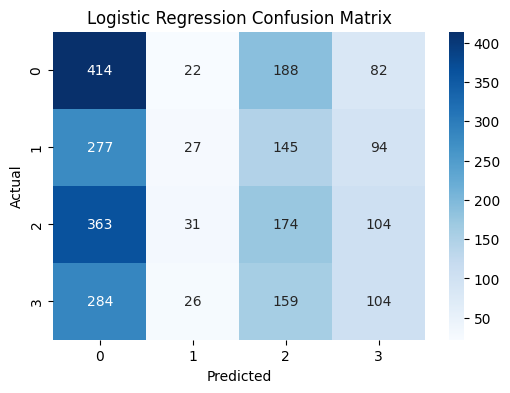

In [32]:
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True,
            fmt='d',
            cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**DECISION TREE**

In [33]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [34]:
y_pred_dt = dt_model.predict(X_test)

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.8849238171611868

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       706
           1       0.87      0.89      0.88       543
           2       0.89      0.89      0.89       672
           3       0.89      0.87      0.88       573

    accuracy                           0.88      2494
   macro avg       0.88      0.88      0.88      2494
weighted avg       0.89      0.88      0.88      2494



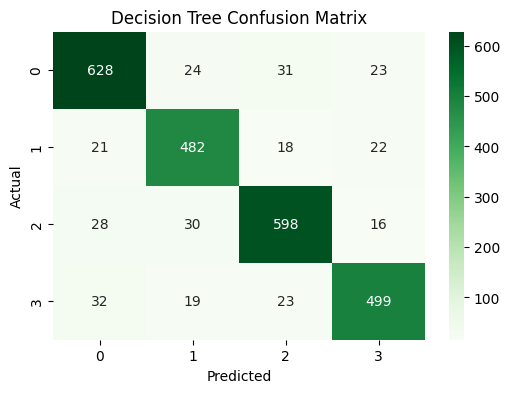

In [36]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt),
            annot=True,
            fmt='d',
            cmap='Greens')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [37]:
from sklearn.metrics import accuracy_score
# Training accuracy
train_pred_dt = dt_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred_dt)

# Testing accuracy
test_accuracy = accuracy_score(y_test, y_pred_dt)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.8849238171611868


**RANDOM FOREST**

In [38]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [39]:
y_pred_rf = rf_model.predict(X_test)

In [40]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8640737770649559

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       706
           1       0.84      0.86      0.85       543
           2       0.88      0.86      0.87       672
           3       0.88      0.83      0.86       573

    accuracy                           0.86      2494
   macro avg       0.86      0.86      0.86      2494
weighted avg       0.86      0.86      0.86      2494



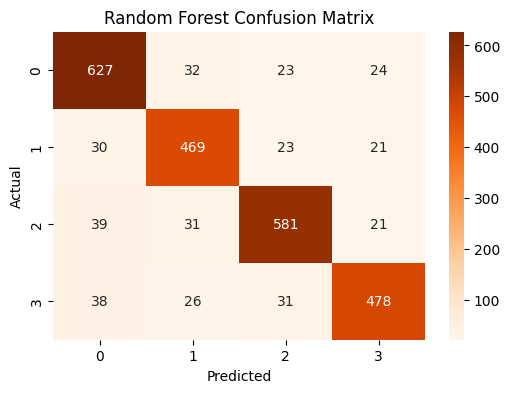

In [41]:
plt.figure(figsize=(6,4))

sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True,
            fmt='d',
            cmap='Oranges')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [42]:
model_results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [ 0.2882, 0.8849, 0.8640]
}
results_df = pd.DataFrame(model_results)
results_df

,Model,Accuracy
0,Logistic Regression,0.2882
1,Decision Tree,0.8849
2,Random Forest,0.8640


In [43]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
feature_importance

,Feature,Importance
8,AssignmentCompletion,0.208970
1,Attendance,0.199684
0,StudyHours,0.186646
6,OnlineCourses,0.178892
10,StressLevel,0.046877
2,Resources,0.041326
4,Motivation,0.038675
9,EduTech,0.032778
7,Discussions,0.029570
3,Extracurricular,0.025005


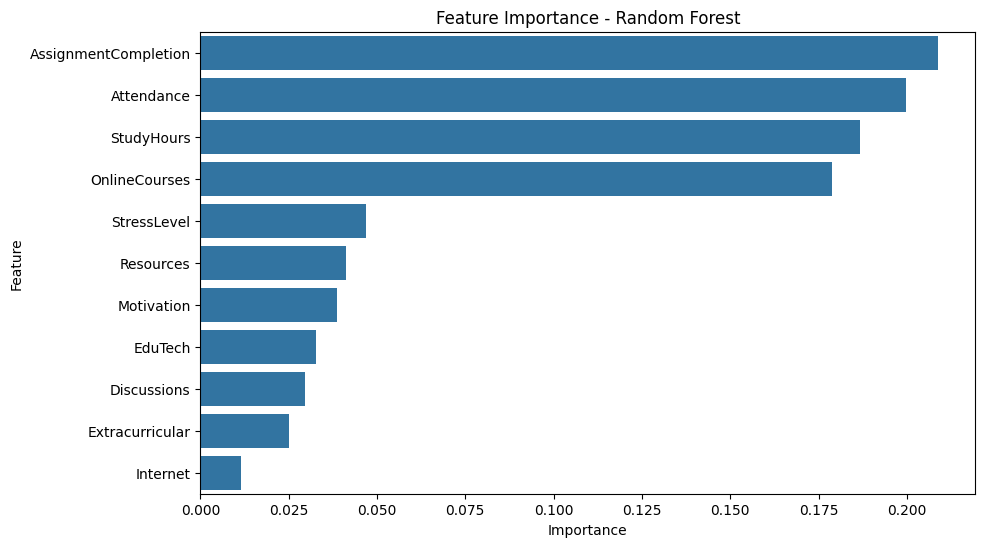

In [44]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)
plt.title('Feature Importance - Random Forest')
plt.show()

# **MODULE 4**

In [45]:
def generate_recommendations(row):
    recommendations = []
    if row['Attendance'] < 75:
        recommendations.append(
            "Improve attendance consistency."
        )
    if row['StudyHours'] < 3:
        recommendations.append(
            "Increase daily study hours."
        )
    if row['StressLevel'] > 7:
        recommendations.append(
            "Practice stress management techniques."
        )
    if row['AssignmentCompletion'] < 70:
        recommendations.append(
            "Complete assignments on time."
        )
    if row['Motivation'] < 5:
        recommendations.append(
            "Engage in motivational learning activities."
        )
    if len(recommendations) == 0:
        recommendations.append(
            "Excellent performance. Keep maintaining consistency."
        )
    return recommendations

In [46]:
sample_student = df.iloc[0]
recommendation_list = generate_recommendations(sample_student)
print(*recommendation_list, sep='\n')

Improve attendance consistency.
Complete assignments on time.
Engage in motivational learning activities.


# **MODULE 5**

In [47]:
import joblib
joblib.dump(dt_model, 'student_performance_model.pkl')

['student_performance_model.pkl']

In [48]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [49]:
X.columns

Index(['StudyHours', 'Attendance', 'Resources', 'Extracurricular',
       'Motivation', 'Internet', 'OnlineCourses', 'Discussions',
       'AssignmentCompletion', 'EduTech', 'StressLevel'],
      dtype='object')

In [50]:
df['Internet'].unique()

array([1, 0])

In [51]:
df['Gender'].unique()

array([0, 1])

In [52]:
df['EduTech'].unique()

array([0, 1])

In [53]:
df['Extracurricular'].unique()

array([0, 1])

In [54]:
df['LearningStyle'].unique()

array([2, 3, 1, 0])

In [55]:
df['Age'].unique()

array([19, 23, 28, 29, 27, 25, 20, 26, 21, 18, 24, 22])

In [56]:
print(feature_importance)

                 Feature  Importance
8   AssignmentCompletion    0.208970
1             Attendance    0.199684
0             StudyHours    0.186646
6          OnlineCourses    0.178892
10           StressLevel    0.046877
2              Resources    0.041326
4             Motivation    0.038675
9                EduTech    0.032778
7            Discussions    0.029570
3        Extracurricular    0.025005
5               Internet    0.011577


In [57]:
print(X.columns.tolist())

['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'EduTech', 'StressLevel']


In [58]:
X.columns

Index(['StudyHours', 'Attendance', 'Resources', 'Extracurricular',
       'Motivation', 'Internet', 'OnlineCourses', 'Discussions',
       'AssignmentCompletion', 'EduTech', 'StressLevel'],
      dtype='object')